In [2]:
%load_ext autoreload
%autoreload 2

import os
os.environ["OPENBLAS_NUM_THREADS"] = "4"  # or a lower number like 2, 4, or 8

import sys, re, torch, time, PINN, palantir
import numpy as np
import pandas as pd
import scanpy as sc
from tqdm.auto import tqdm
# PINN
from PINN import reader, models, pl, tl
# plot
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from matplotlib.backends.backend_pdf import PdfPages

os.chdir("/ssd/users/Wergillius/Project/PINN_dynamics")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# load data

In [3]:
ad_palantir = sc.read_h5ad("data/tom_pos_palantir_Jun4.h5ad")
ad_palantir

AnnData object with n_obs × n_vars = 49390 × 4814
    obs: 'n_genes', 'n_counts', 'mt_count', 'mt_frac', 'doublet_scores', 'predicted_doublets', 'xist_logn', 'Ygene_logn', 'xist_bin', 'Ygene_bin', 'sex_adata', 'biosample_id', 'cellid', 'RBG', 'SLXid', 'index', '10xsample_description', 'sex_mixed', 'sex_meta', 'mouse_id', 'sortedcells', 'expected_cells_10x', 'cellranger_cellsfound', 'chemistry', 'tom', 'expdate', 'batch', 'timepoint_tx_days', 'start_age', 'sample_id', 'countfile', 'S_score', 'G2M_score', 'phase', 'leiden', 'SLX', 'plate_sorted', 'plate_rearranged', 'well_sorted', 'well_rearranged', 'set_index', 'CI_index', 'mouse_platelabel', 'sort_method', 'sample.name', 'population', 'sex', 'countfolder', 'batch_plate_sorted', 'data_type', 'sex_combined', 'longname', 'anno_man', 'leiden_DM', 'HSCscore', 'nn_HSCscore', 'isroot', 'dpt_pseudotime', 'leiden_orig', 'logk', 'net_prolif', 'log10SR', 'log_density_at_E3', 'log_density_at_E7', 'log_density_at_E12', 'log_density_at_E12_clip', 'l

In [4]:
# raw
adata = sc.read_h5ad("data/tom_pos.h5ad")
adata_raw = adata.raw.to_adata()

impute_x_reload = np.load("data/tom_pos_raw_impute_X.npy", allow_pickle=True).item()
adata_raw.layers['MAGIC_imputed_data'] = impute_x_reload

for key in ['g', 'v_sum', 'v_norm', 'nabla_v', 'D', 'DM_EigenVectors_multiscaled', 'palantir_fate_probabilities', 'branch_masks']:
    adata_raw.obsm[key] = ad_palantir.obsm[key].copy()

for key in [ 'DM_Kernel', 'DM_Similarity', 'DM_connectivities', 'DM_distances']:
    adata_raw.obsp[key] = ad_palantir.obsp[key].copy()

adata_raw.obs['palantir_pseudotime'] = ad_palantir.obs['palantir_pseudotime'].copy()

impute_x_reload = np.load("data/tom_pos_raw_impute_X.npy", allow_pickle=True).item()
adata_raw.layers['MAGIC_imputed_data'] = impute_x_reload


In [11]:
adata_raw.obs["Vwf_pos"] = adata_raw[:,'Vwf'].X.A > 0
adata_raw.obs["Vwf_pos"] = adata_raw.obs["Vwf_pos"].map({True: "Vwf+", False: "Vwf-"})

In [12]:
adata_raw.obs['time'] = adata_raw.obs['timepoint_tx_days'].copy()
adata_raw.obs['time'] = adata_raw.obs['time'].astype(str)

In [13]:
ad_Meg = adata_raw[adata_raw.obsm['branch_masks']['Meg']].copy()

# mTOR1 signal different in HSC

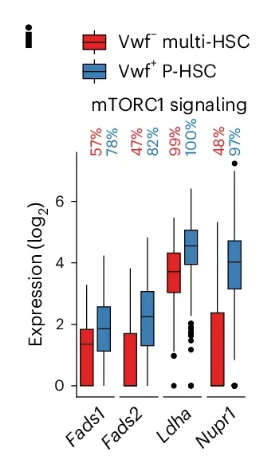

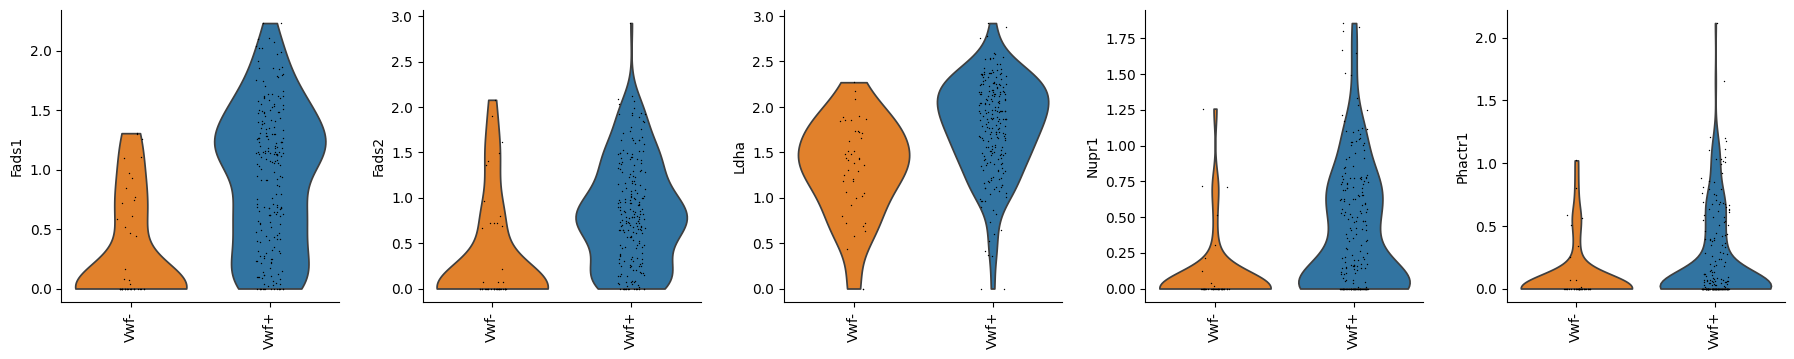

In [161]:
groupby_order = [ "Vwf-", "Vwf+"]
mTol_genes = ["Fads1", "Fads2", "Ldha", "Nupr1", 'Phactr1']
sc.pl.violin(ad_Meg[ad_Meg.obs.query('`timepoint_tx_days` <= 7 & `anno_man` == "HSC"').index], 
             keys=mTol_genes, groupby='Vwf_pos', rotation=90,
            order=groupby_order)

# Vwf+/- gene expression at MK stage

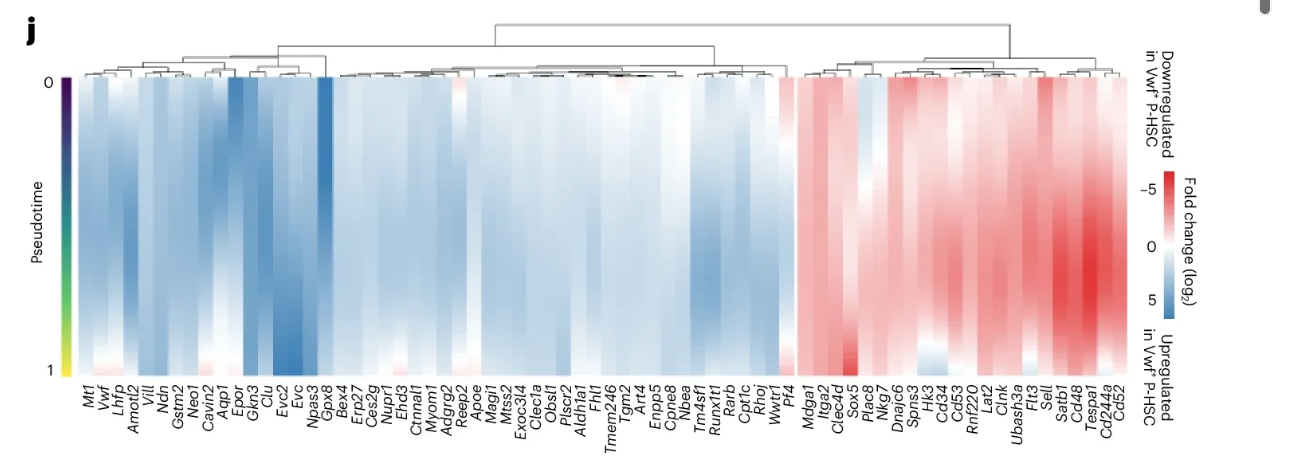

In [14]:
Vwf_MK_sig = {
    "Vwf+ genes":["Evc", "Evc2", "Gkn3", "Ndn", 'Phactr1'],
    "Vwf- genes":["Mdga1", "Itga2", "Clec4d", "Sox5", "Satb1", "Cd48", "Tespa1"]
    }

Text(0.5, 1.0, 'Vwf- MK')

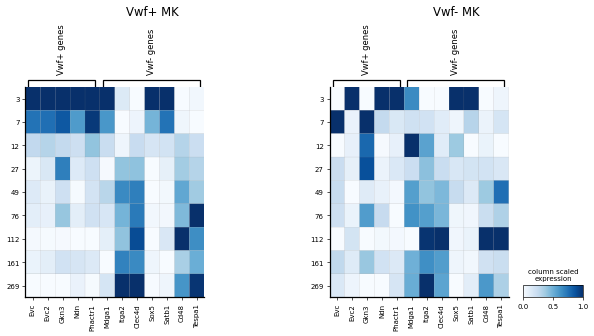

In [190]:
# sc.pl.matrixplot(adata_raw, Vwf_MK_sig, 'Vwf_pos')

fig , axs = plt.subplots(1, 2, figsize=(12, 6), sharex=True, sharey=True, frameon=False, dpi=60)   
mp1 = sc.pl.matrixplot(
    ad_Meg[ad_Meg.obs['Vwf_pos'].isin(['Vwf+'])],
    Vwf_MK_sig,
    'time',
    dendrogram=False,
    cmap="Blues",
    standard_scale="var",
    colorbar_title="column scaled\nexpression",
    ax = axs[0],
    show=False,
)
# axs[0].legend([], frameon=False)
mp1['color_legend_ax'].remove()
axs[0].set_title("Vwf+ MK", fontsize=14)

sc.pl.matrixplot(
    ad_Meg[ad_Meg.obs['Vwf_pos'] == 'Vwf-'],
    Vwf_MK_sig,
    'time',
    dendrogram=False,
    cmap="Blues",
    standard_scale="var",
    colorbar_title="column scaled\nexpression",
    ax = axs[1],
    show=False,
)
axs[1].set_title("Vwf- MK", fontsize=14)

# fig.savefig("figures/tom_pos_MK_Vwf_pos_matrixplot.pdf", bbox_inches='tight')

# compute gene trend seperately

In [15]:
ad_Vwfp = ad_Meg[ad_Meg.obs['Vwf_pos'] == 'Vwf+'].copy()
ad_Vwfn = ad_Meg[ad_Meg.obs['Vwf_pos'] == 'Vwf-'].copy()

In [16]:
#  Compute TF trends along palantir pseudotime
tf_trends = palantir.presults.compute_gene_trends(
    ad_Vwfp,
    expression_key='MAGIC_imputed_data',  # Use the layer with TF activity
    pseudo_time_key='palantir_pseudotime',
)

#  Compute TF trends along palantir pseudotime
tf_trends = palantir.presults.compute_gene_trends(
    ad_Vwfn,
    expression_key='MAGIC_imputed_data',  # Use the layer with TF activity
    pseudo_time_key='palantir_pseudotime',
)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


Bas/MC prog
[2025-06-10 05:15:48,355] [INFO    ] Using sparse Gaussian Process since n_landmarks (500) < n_samples (648) and rank = 1.0.
[2025-06-10 05:15:48,356] [INFO    ] Using covariance function Matern52(ls=1.0).
[2025-06-10 05:15:49,742] [INFO    ] Sigma interpreted as element-wise standard deviation.
Mono/DC prog
[2025-06-10 05:15:50,606] [INFO    ] Using sparse Gaussian Process since n_landmarks (500) < n_samples (544) and rank = 1.0.
[2025-06-10 05:15:50,607] [INFO    ] Using covariance function Matern52(ls=1.0).
[2025-06-10 05:15:51,054] [INFO    ] Sigma interpreted as element-wise standard deviation.
Neu
[2025-06-10 05:15:51,681] [INFO    ] Using sparse Gaussian Process since n_landmarks (500) < n_samples (581) and rank = 1.0.
[2025-06-10 05:15:51,682] [INFO    ] Using covariance function Matern52(ls=1.0).
[2025-06-10 05:15:52,165] [INFO    ] Sigma interpreted as element-wise standard deviation.
Ly
[2025-06-10 05:15:53,308] [INFO    ] Using sparse Gaussian Process since n_la

In [17]:
mk_trend_genes = [
    "Aldh1a1",
    "Car2",
    "Fads2",
    "Clu",
    "Tbxa2r"
]

(<Figure size 1200x400 with 2 Axes>,
 <Axes: xlabel='Pseudotime', ylabel='Aldh1a1 trend'>)

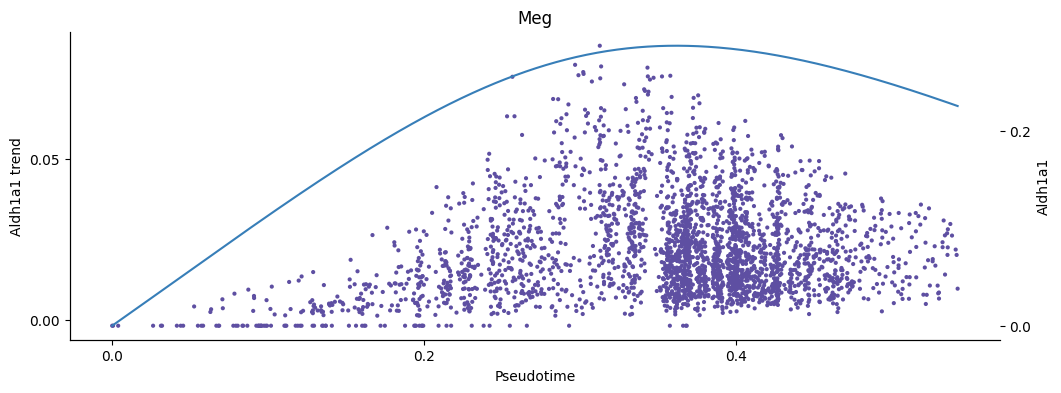

In [18]:
palantir.plot.plot_trend(
    ad_Vwfp,
    "Meg", mk_trend_genes[0],  position_layer="MAGIC_imputed_data", na_color='red', color=None
)

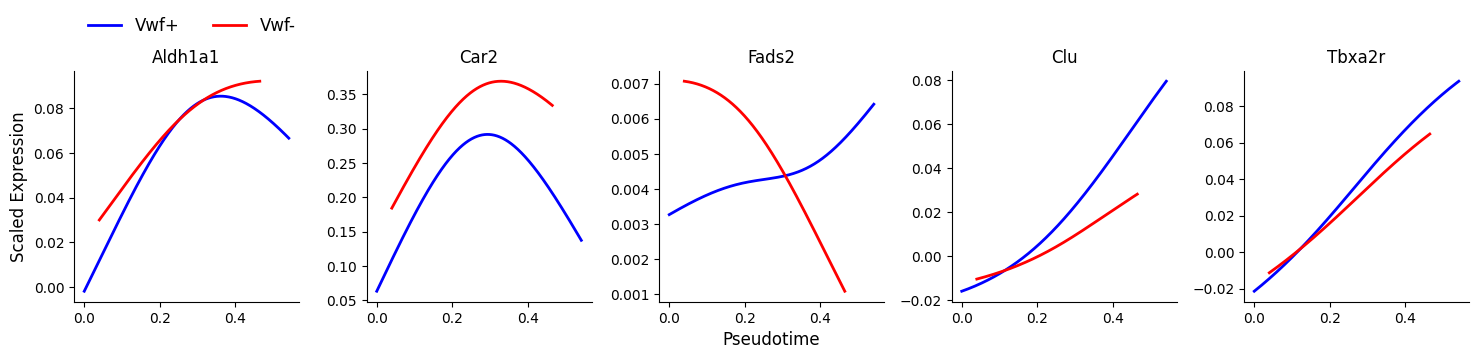

In [19]:
fig, axs = plt.subplots(1, 5, figsize=(18, 3), gridspec_kw={'hspace': 0.3, 'wspace': 0.3}, sharex=True)

Vwfp_df = ad_Vwfp.varm['gene_trends_Meg'].loc[mk_trend_genes].copy()
Vwfn_df = ad_Vwfn.varm['gene_trends_Meg'].loc[mk_trend_genes].copy()
gtx_p = Vwfp_df.columns.astype(float)
gtx_n = Vwfn_df.columns.astype(float)

for i, gene in enumerate(mk_trend_genes):
    
    axs[i].plot(gtx_p, Vwfp_df.loc[gene].values, label="Vwf+", color='blue', lw=2)
    axs[i].plot(gtx_n, Vwfn_df.loc[gene].values, label="Vwf-", color='red', lw=2)

    axs[i].set_title(gene, fontsize=12)

axs[0].set_ylabel('Scaled Expression', fontsize=12)
axs[2].set_xlabel('Pseudotime', fontsize=12)
axs[0].legend(
    ncol=2,
    fontsize=12,
    frameon=False,
    bbox_to_anchor=(1.05, 1.3),
)

In [20]:
ad_Vwfp = ad_Meg[ad_Meg.obs['Vwf_pos'] == 'Vwf+'].copy()
ad_Vwfn = ad_Meg[ad_Meg.obs['Vwf_pos'] == 'Vwf-'].copy()

In [21]:
# by time
ad_meg_early = ad_Meg[ad_Meg.obs.query('`timepoint_tx_days` <= 49  & `Vwf_pos` == "Vwf+"').index].copy() #
ad_meg_late = ad_Meg[ad_Meg.obs.query('`timepoint_tx_days` > 76').index].copy()

In [28]:
#  Compute TF trends along palantir pseudotime
tf_trends = palantir.presults.compute_gene_trends(
    ad_meg_early,
    lineages = ['Meg'],
    expression_key='MAGIC_imputed_data',  # Use the layer with TF activity
    pseudo_time_key='palantir_pseudotime',
)

#  Compute TF trends along palantir pseudotime
tf_trends = palantir.presults.compute_gene_trends(
    ad_meg_late,
    lineages = ['Meg'],
    expression_key='MAGIC_imputed_data',  # Use the layer with TF activity
    pseudo_time_key='palantir_pseudotime',
)

Meg
[2025-06-10 05:20:19,910] [INFO    ] Using sparse Gaussian Process since n_landmarks (500) < n_samples (1,035) and rank = 1.0.
[2025-06-10 05:20:19,911] [INFO    ] Using covariance function Matern52(ls=1.0).
[2025-06-10 05:20:19,957] [INFO    ] Sigma interpreted as element-wise standard deviation.
Meg
[2025-06-10 05:20:21,128] [INFO    ] Using sparse Gaussian Process since n_landmarks (500) < n_samples (2,252) and rank = 1.0.
[2025-06-10 05:20:21,129] [INFO    ] Using covariance function Matern52(ls=1.0).
[2025-06-10 05:20:21,207] [INFO    ] Sigma interpreted as element-wise standard deviation.


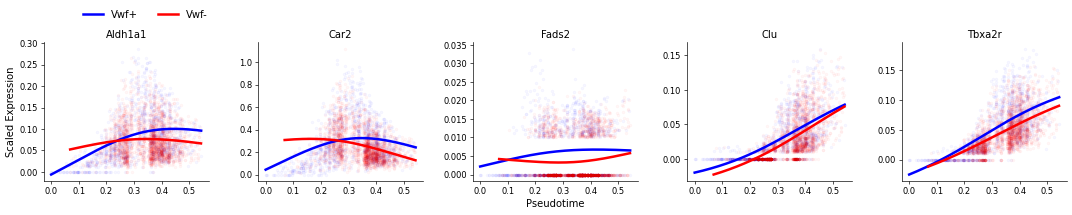

In [71]:
fig, axs = plt.subplots(1, 5, figsize=(22, 3), dpi=60,
            gridspec_kw={'hspace': 0.3, 'wspace': 0.3}, sharex=True)

# for line plot
Vwfp_df = ad_meg_early.varm['gene_trends_Meg'].loc[mk_trend_genes].copy()
Vwfn_df = ad_meg_late.varm['gene_trends_Meg'].loc[mk_trend_genes].copy()
gtx_p = Vwfp_df.columns.astype(float)
gtx_n = Vwfn_df.columns.astype(float)

# for scatter plot
early_x = ad_meg_early.obs['palantir_pseudotime'].astype(float).values
early_y = ad_meg_early[:,mk_trend_genes].layers['MAGIC_imputed_data'].A
late_x = ad_meg_late.obs['palantir_pseudotime'].astype(float).values
late_y = ad_meg_late[:,mk_trend_genes].layers['MAGIC_imputed_data'].A


for i, gene in enumerate(mk_trend_genes):

    # scatter plot
    axs[i].scatter(early_x, early_y[:, i], color='blue', alpha=0.03, s=10)
    axs[i].scatter(late_x, late_y[:, i], color='red', alpha=0.03, s=10)

    # line plot
    axs[i].plot(gtx_p, Vwfp_df.loc[gene].values, label="Vwf+", color='blue', lw=3)
    axs[i].plot(gtx_n, Vwfn_df.loc[gene].values, label="Vwf-", color='red', lw=3)

    axs[i].set_title(gene, fontsize=12)

axs[0].set_ylabel('Scaled Expression', fontsize=12)
axs[2].set_xlabel('Pseudotime', fontsize=12)
axs[0].legend(
    ncol=2,
    fontsize=12,
    frameon=False,
    bbox_to_anchor=(1.05, 1.3),
)

# fig.savefig("figures/tom_pos_MK_Vwf_MK_genetrends_5genes.pdf", bbox_inches='tight')

In [24]:
genes2 = ['Vwf', 'Flt3', 'Cd48']

(-0.015, 0.04)

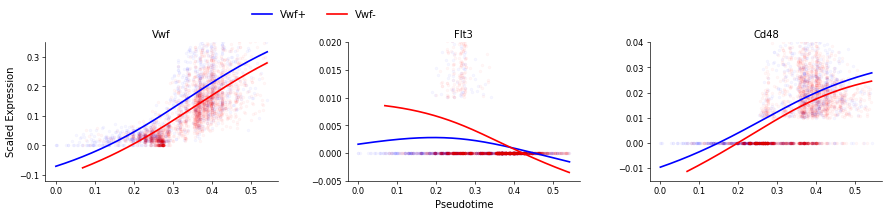

In [74]:
fig, axs = plt.subplots(1, 3, figsize=(18, 3), dpi=60,
                        gridspec_kw={'hspace': 0.3, 'wspace': 0.3}, sharex=True)

Vwfp_df = ad_meg_early.varm['gene_trends_Meg'].loc[genes2].copy()
Vwfn_df = ad_meg_late.varm['gene_trends_Meg'].loc[genes2].copy()
gtx_p = Vwfp_df.columns.astype(float)
gtx_n = Vwfn_df.columns.astype(float)

# for scatter plot
early_x = ad_meg_early.obs['palantir_pseudotime'].astype(float).values
early_y = ad_meg_early[:,genes2].layers['MAGIC_imputed_data'].A
late_x = ad_meg_late.obs['palantir_pseudotime'].astype(float).values
late_y = ad_meg_late[:,genes2].layers['MAGIC_imputed_data'].A

for i, gene in enumerate(genes2):


     # scatter plot
    axs[i].scatter(early_x, early_y[:, i], color='blue', alpha=0.03, s=10)
    axs[i].scatter(late_x, late_y[:, i], color='red', alpha=0.03, s=10)
    
    axs[i].plot(gtx_p, Vwfp_df.loc[gene].values, label="Vwf+", color='blue', lw=2)
    axs[i].plot(gtx_n, Vwfn_df.loc[gene].values, label="Vwf-", color='red', lw=2)

    axs[i].set_title(gene, fontsize=12)

axs[0].set_ylabel('Scaled Expression', fontsize=12)
axs[1].set_xlabel('Pseudotime', fontsize=12)
axs[0].legend(
    ncol=2,
    fontsize=12,
    frameon=False,
    bbox_to_anchor=(0.85, 1.1),
)

axs[0].set_ylim(-0.12, 0.35)
axs[1].set_ylim(-0.005, 0.02)
axs[2].set_ylim(-0.015, 0.04)

# fig.savefig("figures/tom_pos_MK_Vwf_MK_genetrends_3genes.pdf", bbox_inches='tight')

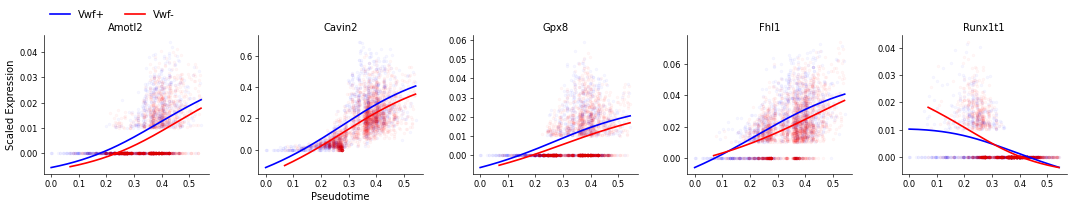

In [76]:
# Intermdiate_genes = ["Amotl2", "Cavin2", "Gkn3", "Clu2", "Gpx8", "Fhl1", "Tm4sf1", "Runx1t1", "Cpt1c"]

Intermdiate_genes = ["Amotl2", "Cavin2",  "Gpx8", "Fhl1", "Runx1t1"]

Intermdiate_genes = [gene for gene in Intermdiate_genes if gene in ad_meg_early.var_names]

fig, axs = plt.subplots(1, 5, figsize=(22, 3), dpi=60,
                        gridspec_kw={'hspace': 0.3, 'wspace': 0.3}, sharex=True)
axs = axs.flatten()

Vwfp_df = ad_meg_early.varm['gene_trends_Meg'].loc[Intermdiate_genes].copy()
Vwfn_df = ad_meg_late.varm['gene_trends_Meg'].loc[Intermdiate_genes].copy()
gtx_p = Vwfp_df.columns.astype(float)
gtx_n = Vwfn_df.columns.astype(float)

# for scatter plot
early_x = ad_meg_early.obs['palantir_pseudotime'].astype(float).values
early_y = ad_meg_early[:,Intermdiate_genes].layers['MAGIC_imputed_data'].A
late_x = ad_meg_late.obs['palantir_pseudotime'].astype(float).values
late_y = ad_meg_late[:,Intermdiate_genes].layers['MAGIC_imputed_data'].A

for i, gene in enumerate(Intermdiate_genes):


     # scatter plot
    axs[i].scatter(early_x, early_y[:, i], color='blue', alpha=0.03, s=10)
    axs[i].scatter(late_x, late_y[:, i], color='red', alpha=0.03, s=10)
    
    axs[i].plot(gtx_p, Vwfp_df.loc[gene].values, label="Vwf+", color='blue', lw=2)
    axs[i].plot(gtx_n, Vwfn_df.loc[gene].values, label="Vwf-", color='red', lw=2)

    axs[i].set_title(gene, fontsize=12)

axs[0].set_ylabel('Scaled Expression', fontsize=12)
axs[1].set_xlabel('Pseudotime', fontsize=12)
axs[0].legend(
    ncol=2,
    fontsize=12,
    frameon=False,
    bbox_to_anchor=(0.85, 1.25),
)

# axs[0].set_ylim(-0.12, 0.35)
# axs[1].set_ylim(-0.005, 0.03)
# axs[2].set_ylim(-0.015, 0.04)


# fig.savefig("figures/tom_pos_MK_Vwf_MK_genetrends_intermediat_genes.pdf", bbox_inches='tight')

# EMP stage

In [49]:
adata_raw.obs['fine_anno'].cat.categories

Index(['HSC', 'Int prog', 'Meg/Ery prog', 'Meg prog', 'Ery prog',
       'Bas/MC prog', 'Eos prog', 'Mono/DC prog', 'Neu prog', 'Ly'],
      dtype='object')

In [63]:
HSC_early = ad_meg_early[ad_meg_early.obs.query('`anno_man` == "Meg/Ery prog"').index].copy() 
Vwfp_df = pd.DataFrame(HSC_early[:,mTol_genes].X.A.copy(), columns=mTol_genes)
Vwfp_df.index = HSC_early.obs_names
Vwfp_df['Vwf_pos'] = HSC_early.obs['Vwf_pos'].copy()


HSC_late = ad_meg_late[ad_meg_late.obs.query('`anno_man` == "Meg/Ery prog"').index].copy() 
Vwfn_df = pd.DataFrame(ad_meg_late[:,mTol_genes].X.A.copy(), columns=mTol_genes)
Vwfn_df.index = ad_meg_late.obs_names
Vwfn_df['Vwf_pos'] = ad_meg_late.obs['Vwf_pos'].copy()

# 
mTol_genes_df = pd.concat([Vwfp_df, Vwfn_df], axis=0)
mTol_genes_df

/ssd/users/Wergillius/miniforge3/envs/PINN_torch/lib/python3.9/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/ssd/users/Wergillius/miniforge3/envs/PINN_torch/lib/python3.9/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


,Fads1,Fads2,Ldha,Nupr1,Phactr1,Vwf_pos
9mo_SIGAE3_AAACGAATCTACGGTA-1-10x,0.000000,0.559884,1.386763,0.916666,0.000000,Vwf+
9mo_SIGAE3_AAAGGATGTCGTCTCT-1-10x,0.667197,0.000000,2.590315,0.000000,0.000000,Vwf+
9mo_SIGAE3_AAATGGATCCTACGAA-1-10x,0.000000,0.000000,0.000000,0.000000,1.007972,Vwf-
9mo_SIGAE3_AACAACCCATATGCGT-1-10x,0.000000,0.000000,2.677060,0.000000,0.000000,Vwf-
9mo_SIGAE3_AACACACCACATCCCT-1-10x,0.000000,0.000000,2.422965,0.000000,0.000000,Vwf-
...,...,...,...,...,...,...
16w_SITTE12_TGCACGGGTAACCCTA-1-10x,0.512458,0.000000,2.339056,0.512458,0.512458,Vwf+
16w_SITTE12_TGTGAGTTCGTGGCTG-1-10x,0.428784,0.000000,2.258239,0.428784,0.727925,Vwf+
16w_SITTE12_TGTTGAGAGGAGCAAA-1-10x,0.303282,0.000000,2.133008,0.000000,0.000000,Vwf+
16w_SITTE12_TTAATCCCAATCTCTT-1-10x,0.000000,0.000000,1.740683,0.000000,0.000000,Vwf+


Text(0, 0.5, 'Scaled Expression')

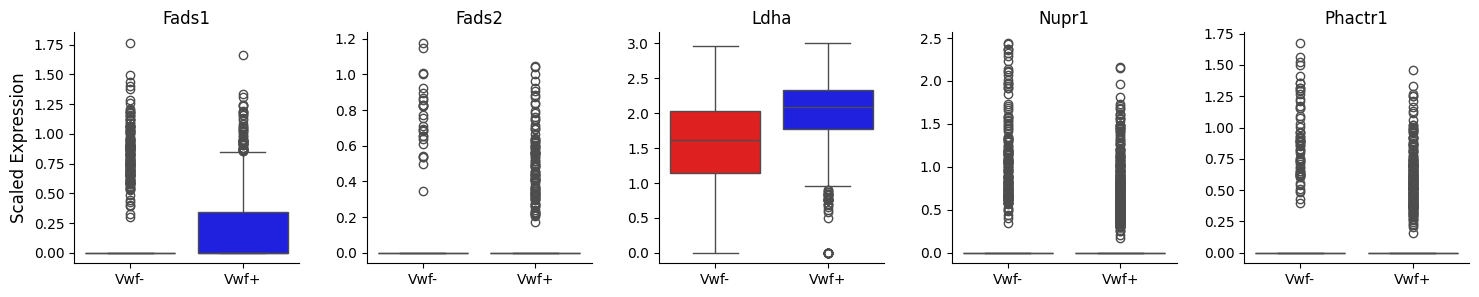

In [64]:
groupby_order = [ "Vwf-", "Vwf+"]
fig, axs = plt.subplots(1, 5, figsize=(18, 3),
            gridspec_kw={'hspace': 0.3, 'wspace': 0.3}, sharex=True)
for i, gene in enumerate(mTol_genes):
    sns.boxplot(
        x='Vwf_pos',
        y=gene,
        data=mTol_genes_df,
        ax=axs[i],
        palette={"Vwf+":'blue', "Vwf-":'red'},
        hue = 'Vwf_pos',
        order=groupby_order,
    )
    axs[i].set_title(gene, fontsize=12)
    axs[i].set_xlabel('')
    axs[i].set_ylabel('')
axs[0].set_ylabel('Scaled Expression', fontsize=12)